# Whistles before dives

For every PVL row flagged `is_dive`, take the window from `BEFORE_S` before to `AFTER_S` after the dive and:

- **Plot 1:** spectrogram of the window, a thick line at the dive, and a box around every whistle hit in the `WHISTLE_WINDOW` before the dive, labelled with its cluster (sub-model) number.
- **Plot 2:** every one of those whistles, one row each, aligned to its sub-model's match states, laid out like `processing.py` / `lib_phmm.visualization.extract_match_wav`: each state gets a fixed number of frame slots, so the same state lines up across rows.

Plot 2 needs the handler state downloaded from Drive (`motif_extend_state/phmm_extended.pkl` and `motif_embeddings_cache/<recording>.v2.pkl`); it is skipped if either is missing.

In [1]:
import os
import sys
import glob
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import librosa
import soundfile as sf

REPO = os.path.abspath('..')
sys.path.insert(0, REPO)
import lib_phmm.profile_hmm  # needed to unpickle the model

%matplotlib inline

In [2]:
# ---- configuration ----
PVL_PATH   = '/Users/dkohlsdorf/Documents/pvl_merge/motif_extend_find_fixed_exact_decode_filtered_relax_th/pvl_annotated_audio.csv'
AUDIO_ROOT = '/Users/dkohlsdorf/Documents/audio/wdp_data_at_google'   # searched recursively for .wav / .m4a
HITS_ROOT  = os.path.dirname(PVL_PATH)   # <recording>/motif_hits.csv, for exact hit times (PVL timecodes are whole seconds)

# handler state downloaded from Drive -- Plot 2 is skipped until both exist
HANDLER_STATE      = os.path.join(REPO, 'motif', 'handler_state')
EMBEDDINGS_DIR     = os.path.join(HANDLER_STATE, 'motif_embeddings_cache')   # <recording>.<version>.pkl
EMBEDDINGS_VERSION = 'v2'
MODEL_PATH         = os.path.join(HANDLER_STATE, 'motif_extend_state', 'phmm_extended.pkl')

BEFORE_S        = 10.0            # window starts this long before the dive
AFTER_S         = 5.0             # ... and ends this long after it
WHISTLE_WINDOW  = (-10.0, 0.0)    # whistles overlapping this range (s, relative to the dive) are marked
WHISTLE_CLASSES = ['WHISTLE']     # shotlog::AC values of motif rows to treat as whistles
ONLY_WITH_WHISTLES = True         # skip dives with no whistle in WHISTLE_WINDOW
MAX_DIVES       = None            # cap on dives plotted; None = all

N_FFT       = 1024
HOP         = 256
FMAX_HZ     = 30000               # spectrogram y-limit; None = Nyquist
BOX_BAND_HZ = (3000, 25000)       # band searched for a whistle's peak frequency to size its box
BOX_PAD_HZ  = 1000

FRAMES_PER_COLUMN = 2             # frame slots per match state in the aligned plot (as in processing.py)

## Load PVL, locate audio, find dives

In [3]:
def find_files(root, name):
    return sorted(glob.glob(os.path.join(glob.escape(root), '**', name), recursive=True))


audio_index = {}
for ext in ('m4a', 'wav'):   # wav preferred over m4a
    for p in find_files(AUDIO_ROOT, '*.' + ext):
        audio_index[os.path.splitext(os.path.basename(p))[0]] = p

pvl = pd.read_csv(PVL_PATH)
pvl['recording'] = pvl.audio_path.str.replace(r'\.(wav|m4a)$', '', regex=True)
pvl['t_s'] = pd.to_timedelta(pvl['shotlog::timecode'], errors='coerce').dt.total_seconds()
pvl['cluster'] = pd.to_numeric(pvl['shotlog::BEHdescription'], errors='coerce')
pvl['is_dive'] = pvl['is_dive'].astype('boolean').fillna(False)

missing = sorted(set(pvl.recording) - set(audio_index))
print(f'{len(pvl)} PVL rows, {pvl.recording.nunique()} recordings, {int(pvl.is_dive.sum())} dive rows')
if missing:
    print(f'WARNING: no audio under {AUDIO_ROOT} for: {missing}')

7131 PVL rows, 28 recordings, 107 dive rows


In [4]:
_hits_cache = {}


def motif_hits(recording):
    if recording not in _hits_cache:
        p = os.path.join(HITS_ROOT, recording, 'motif_hits.csv')
        _hits_cache[recording] = pd.read_csv(p) if os.path.exists(p) else None
    return _hits_cache[recording]


def exact_span(row):
    # PVL motif rows keep the start rounded down to the second; recover the exact hit
    # (and its sample span) from motif_hits.csv by cluster, start second and duration
    hits = motif_hits(row.recording)
    if hits is not None:
        m = hits[(hits.submodel_id == row.cluster)
                 & (hits.start_time_s.astype(int) == int(row.t_s))
                 & ((hits.stop_time_s - hits.start_time_s - row.duration_s).abs() < 1e-3)]
        if len(m):
            h = m.iloc[0]
            return h.start_time_s, h.stop_time_s, int(h.start_sample), int(h.stop_sample), True
    return row.t_s, row.t_s + row.duration_s, None, None, False


def whistles_near(dive):
    lo, hi = dive.t_s + WHISTLE_WINDOW[0], dive.t_s + WHISTLE_WINDOW[1]
    rec = pvl[(pvl.recording == dive.recording)
              & pvl['shotlog::AC'].isin(WHISTLE_CLASSES) & pvl.cluster.notna()
              & (pvl.t_s <= hi + 1) & (pvl.t_s + pvl.duration_s >= lo - 1)]
    rows = []
    for _, r in rec.iterrows():
        start, stop, s0, s1, exact = exact_span(r)
        if stop >= lo and start <= hi:
            rows.append(dict(cluster=int(r.cluster), start_s=start, stop_s=stop,
                             start_sample=s0, stop_sample=s1, exact=exact,
                             score=pd.to_numeric(r['SPECIAL COMMENTS'], errors='coerce')))
    return pd.DataFrame(rows, columns=['cluster', 'start_s', 'stop_s', 'start_sample', 'stop_sample', 'exact', 'score'])


dives = []
for i, d in pvl[pvl.is_dive & pvl.t_s.notna() & pvl.recording.isin(audio_index)].iterrows():
    w = whistles_near(d)
    if ONLY_WITH_WHISTLES and w.empty:
        continue
    dives.append(dict(row=i, recording=d.recording, t_s=d.t_s,
                      behaviour=d['shotlog::BEHdescription'], whistles=w))
n_inexact = sum((~d['whistles'].exact).sum() for d in dives)
print(f'{len(dives)} dives with whistles, {sum(len(d["whistles"]) for d in dives)} whistles'
      + (f' ({n_inexact} without an exact motif_hits.csv match -- whole-second timing)' if n_inexact else ''))
if MAX_DIVES is not None:
    dives = dives[:MAX_DIVES]
    print(f'plotting the first {len(dives)}')
pd.DataFrame([{k: v for k, v in d.items() if k != 'whistles'} | {'n_whistles': len(d['whistles']),
               'clusters': sorted(set(d['whistles'].cluster))} for d in dives])

21 dives with whistles, 44 whistles


,row,recording,t_s,behaviour,n_whistles,clusters
0,1032,07312401_EAGLE_TASCAM,922.0,U DIVES AND CIRCLES BACK UP,1,[507]
1,1221,07312401_EAGLE_TASCAM,1552.0,CHRIS DIVES WITH DOLPHINS,1,[619]
2,1722,07312401_EAGLE_TASCAM,3687.0,DOLPHINS DIVE,2,"[376, 583]"
3,2174,07032401_SKATE_TASCAM,361.0,U DIVES,1,[561]
4,2176,07032401_SKATE_TASCAM,369.0,BRITTINI DIVES WITH SARGASSUM,1,[425]
5,2439,06052401_SKATE_TASCAM (jump 2),344.0,DOLPHINS GROUP UP AND DIVE,4,"[167, 500, 563]"
6,2657,06052401_SKATE_TASCAM (jump 1),344.0,DOLPHINS GROUP UP AND DIVE,4,"[468, 561, 619, 624]"
7,2995,05272401_SKATE_TASCAM,463.0,TWO DOLPHINS DIVE,2,"[437, 583]"
8,3257,05272401_SKATE_TASCAM,1362.0,DOLPHINS DIVE,2,"[439, 507]"
9,3314,05222401_SKATE_TASCAM,253.0,THREE DOLPHINS DIVE,4,"[371, 501, 596, 605]"


## Audio and spectrogram helpers

In [5]:
def load_clip(path, start_s, stop_s):
    # wav: seek directly; m4a: decode just the window via ffmpeg (librosa/audioread)
    start_s = max(0.0, start_s)
    if path.lower().endswith('.wav'):
        sr = sf.info(path).samplerate
        x, sr = sf.read(path, start=int(start_s * sr), stop=int(stop_s * sr), always_2d=True)
        x = x.mean(axis=1)
    else:
        x, sr = librosa.load(path, sr=None, mono=True, offset=start_s, duration=stop_s - start_s)
    return x.astype(np.float32), sr, start_s


def spectrogram(x, sr):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(x, n_fft=N_FFT, hop_length=HOP)), ref=np.max)
    return S, librosa.fft_frequencies(sr=sr, n_fft=N_FFT)


def show_spec(ax, S, sr, t0, t1):
    ax.imshow(S, origin='lower', aspect='auto', cmap='magma', vmin=-80, vmax=0, extent=[t0, t1, 0, sr / 2])
    ax.set_ylim(0, FMAX_HZ or sr / 2)
    ax.set_ylabel('Hz')


def box_band(S, freqs, t0, sr, start_s, stop_s):
    # peak frequency per spectrogram column inside BOX_BAND_HZ, 5th-95th percentile, padded
    c0 = max(0, int((start_s - t0) * sr / HOP))
    c1 = min(S.shape[1], int(np.ceil((stop_s - t0) * sr / HOP)) + 1)
    band = (freqs >= BOX_BAND_HZ[0]) & (freqs <= BOX_BAND_HZ[1])
    if c1 <= c0 or not band.any():
        return BOX_BAND_HZ
    peaks = freqs[band][np.argmax(S[band, c0:c1], axis=0)]
    lo, hi = np.percentile(peaks, [5, 95])
    return max(0.0, lo - BOX_PAD_HZ), min(sr / 2, hi + BOX_PAD_HZ)


def cluster_colors(clusters):
    cmap = plt.get_cmap('tab10')
    return {c: cmap(i % 10) for i, c in enumerate(sorted(set(clusters)))}


def dive_window(dive):
    x, sr, t0 = load_clip(audio_index[dive['recording']], dive['t_s'] - BEFORE_S, dive['t_s'] + AFTER_S)
    S, freqs = spectrogram(x, sr)
    return x, sr, t0, S, freqs


def draw_window(ax, dive, sr, t0, S, freqs, boxes=True):
    t = dive['t_s']
    t1 = t0 + S.shape[1] * HOP / sr
    show_spec(ax, S, sr, t0 - t, t1 - t)   # time axis relative to the dive
    ax.axvline(0, color='cyan', lw=4)
    ax.axvspan(WHISTLE_WINDOW[0], WHISTLE_WINDOW[1], color='w', alpha=0.05, lw=0)
    colors = cluster_colors(dive['whistles'].cluster)
    for _, w in dive['whistles'].iterrows():
        c = colors[w.cluster]
        if boxes:
            lo, hi = box_band(S, freqs, t0, sr, w.start_s, w.stop_s)
            ax.add_patch(Rectangle((w.start_s - t, lo), w.stop_s - w.start_s, hi - lo,
                                   fill=False, ec=c, lw=2, ls='-' if w.exact else '--'))
            ax.text(w.start_s - t, hi, f' {w.cluster}', color='k', fontsize=8, va='top', ha='left',
                    bbox=dict(fc=c, ec='none', pad=1, alpha=0.9))
        else:
            ax.axvspan(w.start_s - t, w.stop_s - t, color=c, alpha=0.25, lw=0)
    ax.set_xlabel('seconds relative to dive')
    ax.set_title(f"{dive['recording']} @ {dive['t_s']:.0f}s -- {dive['behaviour']}", fontsize=9, loc='left')

## Plot 1: whistles before each dive

Solid boxes use exact hit times from `motif_hits.csv`; dashed boxes fall back to the PVL's whole-second timecode.

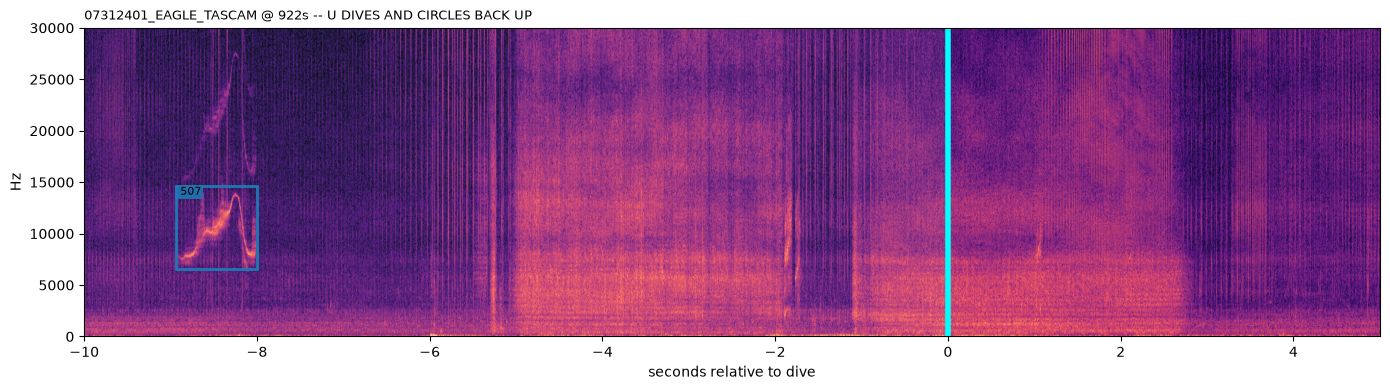

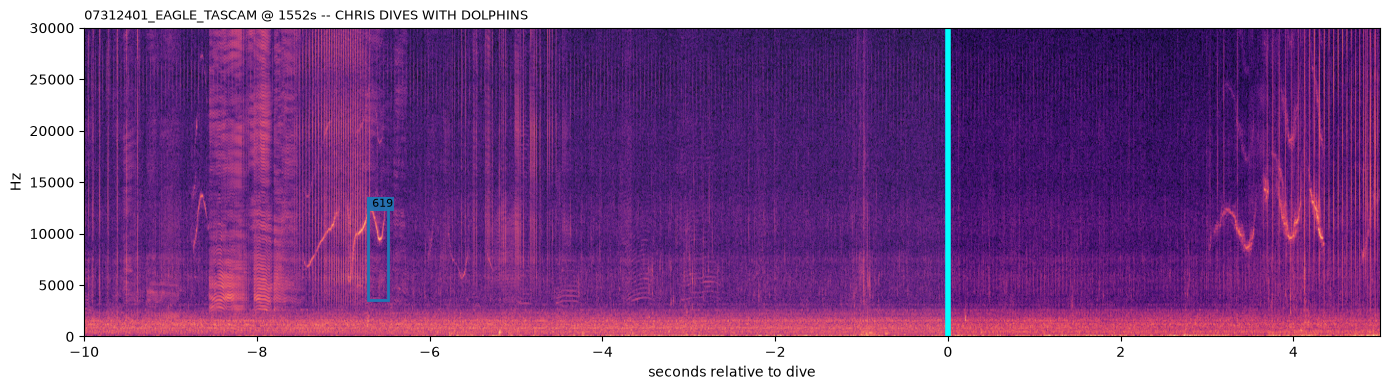

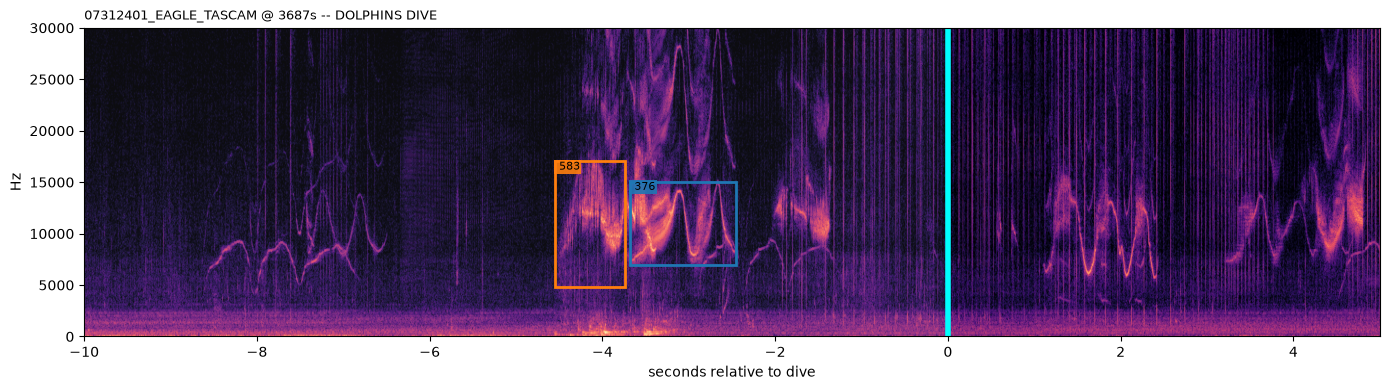

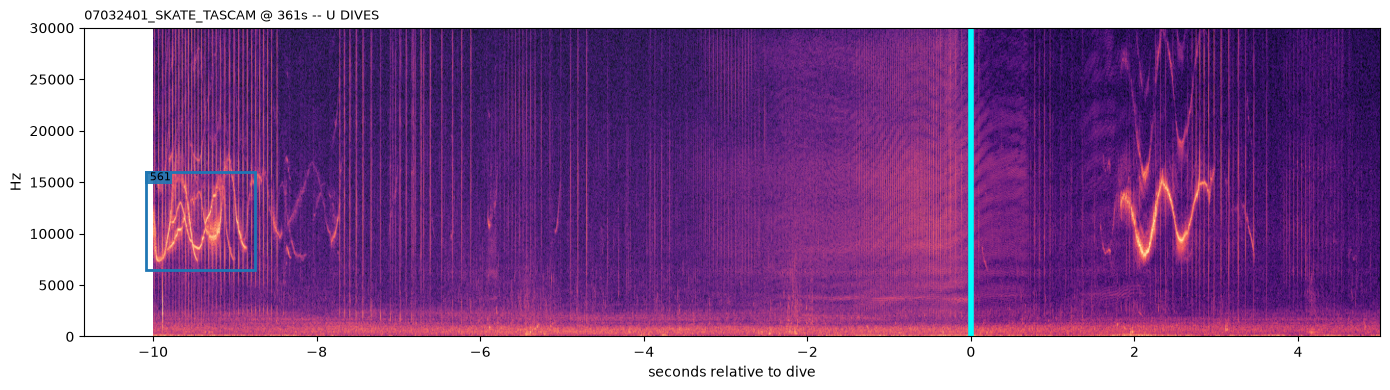

In [ ]:
for dive in dives:
    x, sr, t0, S, freqs = dive_window(dive)
    fig, ax = plt.subplots(figsize=(14, 4))
    draw_window(ax, dive, sr, t0, S, freqs, boxes=True)
    plt.tight_layout()
    plt.show()

## Plot 2: whistles aligned to their sub-model's match states

Each whistle's frames are Viterbi-aligned to its own sub-model with the same rules as `profile_hmm.hpp`'s full-match decode: enter at the first state, end at the sub-model's last real state (`last_match`), self-loops cost `mm`, moving on is free. Every state then gets `FRAMES_PER_COLUMN` slots of `step_samples` audio each (silence where the state had fewer frames), with the sub-models present in the window laid out side by side, as in `processing.py`.

In [ ]:
have_state = os.path.exists(MODEL_PATH) and os.path.isdir(EMBEDDINGS_DIR)
if not have_state:
    print(f'Plot 2 skipped: need {MODEL_PATH} and {EMBEDDINGS_DIR}')
else:
    with open(MODEL_PATH, 'rb') as f:
        model_record = pickle.load(f)
    hmm = model_record['hmm']
    print(f"model: {model_record['n_models']} sub-models, cap {model_record['n_match_states']}")

_emb_cache = {}


def embeddings_for(recording):
    if recording not in _emb_cache:
        p = os.path.join(EMBEDDINGS_DIR, f'{recording}.{EMBEDDINGS_VERSION}.pkl')
        with open(p, 'rb') as f:
            emb, _, step_samples, emb_sr = pickle.load(f)
        _emb_cache[recording] = (np.asarray(emb), step_samples, emb_sr)
    return _emb_cache[recording]


def align_to_submodel(frames, n):
    # left-to-right Viterbi over sub-model n's real states 1..last_match[n];
    # returns the state (1-based) of every frame
    last = hmm.last_match[n]
    ll = np.array([[hmm.pdf[n][k].ll(f.tolist()) / np.log(2) for k in range(1, last + 1)] for f in frames])
    stay = np.array(hmm.trans.mm[n][1:last + 1])
    T, K = ll.shape
    W = np.full((T, K), -np.inf)
    back = np.zeros((T, K), dtype=int)
    W[0, 0] = ll[0, 0]
    for t in range(1, T):
        from_self = W[t - 1] + stay
        from_prev = np.concatenate([[-np.inf], W[t - 1, :-1]])
        back[t] = np.where(from_prev > from_self, -1, 0)
        W[t] = ll[t] + np.maximum(from_self, from_prev)
    full = bool(np.isfinite(W[-1, -1]))
    k = K - 1 if full else int(np.argmax(W[-1]))   # fewer frames than states: end where it got to
    states = [k]
    for t in range(T - 1, 0, -1):
        k += back[t, k]
        states.append(k)
    return np.array(states[::-1]) + 1, full


def whistle_frames(w, step_samples, emb_sr):
    if w.exact:
        return int(w.start_sample) // step_samples, int(w.stop_sample) // step_samples
    return int(w.start_s * emb_sr / step_samples), int(np.ceil(w.stop_s * emb_sr / step_samples))


def aligned_audio(x, sr, t0, frame_states, frame_idx, models, step_s):
    # fixed-width layout: for each sub-model in `models`, for each of its states,
    # FRAMES_PER_COLUMN slots of one frame hop of audio each
    slot = int(round(step_s * sr))
    by_state = {}
    for f, s in zip(frame_idx, frame_states):
        by_state.setdefault(s, []).append(f)
    clips, real = [], []
    for n in models:
        for k in range(1, hmm.last_match[n] + 1):
            fs = by_state.get((n, k), [])[:FRAMES_PER_COLUMN]
            for j in range(FRAMES_PER_COLUMN):
                if j < len(fs):
                    a = int(round((fs[j] * step_s - t0) * sr))
                    clip = x[max(0, a):max(0, a) + slot]
                    clip = np.pad(clip, (0, slot - len(clip)))
                    real.append((len(clips) * slot, n))
                else:
                    clip = np.zeros(slot, dtype=np.float32)
                clips.append(clip)
    return np.concatenate(clips), real, slot

In [ ]:
if have_state:
    for dive in dives:
        x, sr, t0 = load_clip(audio_index[dive['recording']], dive['t_s'] - BEFORE_S, dive['t_s'] + AFTER_S)
        emb, step_samples, emb_sr = embeddings_for(dive['recording'])
        step_s = step_samples / emb_sr
        whistles = dive['whistles']
        models = sorted(set(whistles.cluster))
        colors = cluster_colors(whistles.cluster)

        rows = []
        for _, w in whistles.iterrows():
            f0, f1 = whistle_frames(w, step_samples, emb_sr)
            frames = emb[f0:f1]
            if len(frames) == 0:
                continue
            states, _ = align_to_submodel(frames, w.cluster)
            audio, real, slot = aligned_audio(x, sr, t0, [(w.cluster, s) for s in states],
                                              range(f0, f1), models, step_s)
            rows.append((w, audio, real, slot))

        if not rows:
            continue
        fig, axes = plt.subplots(len(rows), 1, figsize=(14, 0.6 + 1.8 * len(rows)), sharex=True, squeeze=False)
        axes = axes[:, 0]
        fig.suptitle(f"{dive['recording']} @ {dive['t_s']:.0f}s -- {dive['behaviour']}: "
                     f"{len(rows)} whistles aligned to their sub-models", fontsize=10, x=0.01, ha='left')

        for ax, (w, audio, real, slot) in zip(axes, rows):
            A, _ = spectrogram(audio, sr)
            show_spec(ax, A, sr, 0, len(audio) / sr)
            for start, n in real:
                ax.axvspan(start / sr, (start + slot) / sr, ymin=0.95, ymax=1.0, color=colors[n], lw=0)
            edge = 0
            for n in models:   # sub-model block boundaries
                edge += hmm.last_match[n] * FRAMES_PER_COLUMN * slot
                ax.axvline(edge / sr, color='w', lw=0.8, ls=':')
            ax.set_ylabel(f'{w.cluster}\n{w.start_s - dive["t_s"]:+.1f}s', rotation=0, ha='right', va='center',
                          color=colors[w.cluster], fontsize=9)
            ax.set_yticks([])
            ax.tick_params(labelsize=7)
        axes[-1].set_xlabel('aligned time (s): sub-model blocks left to right ' + ', '.join(map(str, models)))
        plt.tight_layout()
        plt.show()